# Resume RAG & Job Matching System

## Project Overview

This project implements a Retrieval-Augmented Generation (RAG)-based
resume retrieval and job matching system.

The system processes resumes, extracts structured metadata, generates
semantic embeddings, stores resume chunks in a vector database, and
matches candidates against job descriptions.

### Key Features

- Resume document processing
- Section-aware document chunking
- Metadata extraction
- Semantic embeddings
- ChromaDB vector storage
- Semantic search
- Hybrid skill matching
- Must-have requirement filtering
- Candidate ranking
- Match reasoning
- Retrieval evaluation
- Latency measurement

### Dataset

- 32 resumes
- 6 job descriptions
- 160 indexed resume chunks
- 384-dimensional embeddings
- Sentence Transformer: `all-MiniLM-L6-v2`
- Vector database: ChromaDB

In [1]:
import sys
import json
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append("..")

from src.resume_rag import ResumeRAG
from src.job_matcher import JobMatcher

print("Libraries imported successfully")

Libraries imported successfully


## 1. Dataset Overview

The experiment uses a synthetic dataset containing 32 resumes
representing different technical domains and 6 job descriptions.

The resumes cover areas such as:

- Backend
- Machine Learning
- AI
- Data Science
- DevOps
- Cloud
- Frontend
- Full Stack

In [2]:
resume_dir = Path("../resumes")
job_dir = Path("../job_descriptions")

resume_files = list(resume_dir.glob("*.txt"))
job_files = list(job_dir.glob("*.txt"))

print("Number of resumes:", len(resume_files))
print("Number of job descriptions:", len(job_files))

Number of resumes: 32
Number of job descriptions: 6


In [3]:
resume_data = []

for resume_file in sorted(resume_files):
    resume_data.append({
        "Candidate": resume_file.stem.replace("_", " ").title(),
        "File": resume_file.name
    })

resume_df = pd.DataFrame(resume_data)

resume_df.head(10)

,Candidate,File
0,Aakash Reddy,aakash_reddy.txt
1,Aditya Patel,aditya_patel.txt
2,Ananya Iyer,ananya_iyer.txt
3,Aravind Kumar,aravind_kumar.txt
4,Arun Kumar,arun_kumar.txt
5,Deepa Joseph,deepa_joseph.txt
6,Divya Menon,divya_menon.txt
7,Ganesh B,ganesh_b.txt
8,Harini S,harini_s.txt
9,Ishita Roy,ishita_roy.txt


## 2. RAG System

The RAG pipeline consists of:

1. Resume loading
2. Section-aware chunking
3. Metadata extraction
4. Embedding generation
5. ChromaDB storage
6. Semantic retrieval

In [4]:
rag = ResumeRAG(
    resume_directory="../resumes",
    chroma_directory="../chroma_db"
)

matcher = JobMatcher(rag)

print("RAG system loaded successfully")

Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding model loaded successfully
RAG system loaded successfully


## 3. Embedding Generation

The project uses the `all-MiniLM-L6-v2` Sentence Transformer model
to generate semantic embeddings.

Each embedding contains 384 dimensions.

Embeddings allow the system to compare the semantic similarity
between job descriptions and resume content.

In [5]:
sample_text = """
Python backend engineer with experience in FastAPI,
Django, PostgreSQL, Docker and AWS.
"""

embedding = rag.embedding_model.embed_text(
    sample_text
)

print("Embedding dimensions:", len(embedding))
print("First 10 values:", embedding[:10])

Embedding dimensions: 384
First 10 values: [-0.048104800283908844, -0.0034696892835199833, -0.018143024295568466, 0.05947928503155708, -0.036992620676755905, -0.1266166865825653, -0.052693936973810196, -0.0021135052666068077, -0.0569823682308197, -0.05690294876694679]


## 4. Semantic Search

A job description is converted into an embedding and compared
against resume chunk embeddings stored in ChromaDB.

The nearest chunks represent the most semantically relevant
resume content.

In [6]:
query = """
Python backend engineer with 5+ years of experience
using FastAPI, Django, PostgreSQL, Docker and AWS.
"""

search_results = matcher.semantic_search(
    query,
    top_k=10
)

print("Retrieved chunks:", len(
    search_results["documents"][0]
))

Retrieved chunks: 10


In [7]:
for i, (document, metadata) in enumerate(
    zip(
        search_results["documents"][0],
        search_results["metadatas"][0]
    ),
    start=1
):

    print("=" * 60)
    print(f"Result {i}")
    print("Candidate:", metadata["candidate_name"])
    print("Section:", metadata["section"])
    print("Text:", document)

Result 1
Candidate: Sathish Kumar
Section: Skills
Text: Python, Django, FastAPI, PostgreSQL, Docker, AWS
Result 2
Candidate: Lakshmi Devi
Section: Skills
Text: Python, Django, FastAPI, PostgreSQL, AWS, Docker
Result 3
Candidate: Arun Kumar
Section: Skills
Text: Python, Django, FastAPI, PostgreSQL, Docker, AWS, Git
Result 4
Candidate: Swetha R
Section: Skills
Text: Python, FastAPI, PostgreSQL, AWS, Docker
Result 5
Candidate: Arun Kumar
Section: Experience
Text: 6 years of experience developing backend applications and REST APIs using Python, Django and FastAPI.
Result 6
Candidate: Vikram Singh
Section: Skills
Text: Python, FastAPI, PostgreSQL, Redis, Docker, AWS
Result 7
Candidate: Suresh Kumar
Section: Skills
Text: Python, FastAPI, Django, MySQL, Docker
Result 8
Candidate: Sanjay Rao
Section: Skills
Text: Python, FastAPI, PostgreSQL, Redis, AWS
Result 9
Candidate: Manoj Kumar
Section: Skills
Text: Python, Flask, PostgreSQL, Docker, AWS
Result 10
Candidate: Vikram Singh
Section: Experie

## 5. Job Matching

The job matching engine combines semantic similarity with
structured skill and experience matching.

The scoring model uses:

- Semantic similarity: 35%
- Technical skill match: 40%
- Experience match: 15%
- Domain match: 10%

In [8]:
job_file = job_dir / "python_backend_engineer.txt"

job_description = job_file.read_text(
    encoding="utf-8"
)

start_time = time.perf_counter()

result = matcher.match_job(
    job_description,
    top_k=10
)

end_time = time.perf_counter()

latency_ms = (
    end_time - start_time
) * 1000

print(f"Matching latency: {latency_ms:.2f} ms")

Matching latency: 149.69 ms


In [9]:
top_matches = result["top_matches"]

matching_df = pd.DataFrame([
    {
        "Rank": rank,
        "Candidate": candidate["candidate_name"],
        "Score": candidate["match_score"],
        "Matched Skills": ", ".join(
            candidate["matched_skills"]
        ),
        "Reasoning": candidate["reasoning"]
    }
    for rank, candidate in enumerate(
        top_matches,
        start=1
    )
])

matching_df

,Rank,Candidate,Score,Matched Skills,Reasoning
0,1,Sathish Kumar,83.71,"python, django, fastapi, postgresql, aws, docker",Candidate has 5 years of experience against th...
1,2,Lakshmi Devi,83.49,"python, django, fastapi, postgresql, aws, docker",Candidate has 7 years of experience against th...
2,3,Arun Kumar,82.47,"python, django, fastapi, postgresql, aws, docker",Candidate has 6 years of experience against th...
3,4,Swetha R,74.91,"python, fastapi, postgresql, aws, docker",Candidate has 6 years of experience against th...
4,5,Vikram Singh,73.56,"python, fastapi, postgresql, aws, docker",Candidate has 8 years of experience against th...
5,6,Sanjay Rao,65.51,"python, fastapi, postgresql, aws",Candidate has 9 years of experience against th...
6,7,Manoj Kumar,54.98,"python, postgresql, aws, docker",Candidate has 5 years of experience against th...
7,8,Karthik Raj,29.25,"aws, docker",Candidate has 6 years of experience against th...
8,9,Priya Sharma,28.33,"python, aws",Candidate has 5 years of experience against th...


In [10]:
for candidate in top_matches[:3]:

    print("=" * 70)
    print("Candidate:", candidate["candidate_name"])
    print("Score:", candidate["match_score"])

    print("\nMatched Skills:")
    print(candidate["matched_skills"])

    print("\nRelevant Excerpts:")

    for excerpt in candidate["relevant_excerpts"]:
        print("-", excerpt)

    print("\nReasoning:")
    print(candidate["reasoning"])

Candidate: Sathish Kumar
Score: 83.71

Matched Skills:
['python', 'django', 'fastapi', 'postgresql', 'aws', 'docker']

Relevant Excerpts:
- Python, Django, FastAPI, PostgreSQL, Docker, AWS
- 5 years of experience developing Python backend applications.
- Built REST APIs and deployed backend applications on AWS.

Reasoning:
Candidate has 5 years of experience against the required 5+ years and matched 6 of 6 required skills. Relevant resume sections: Skills, Experience, Projects.
Candidate: Lakshmi Devi
Score: 83.49

Matched Skills:
['python', 'django', 'fastapi', 'postgresql', 'aws', 'docker']

Relevant Excerpts:
- Python, Django, FastAPI, PostgreSQL, AWS, Docker
- 7 years of experience developing Python backend systems.
- Built scalable backend APIs and cloud-native applications.

Reasoning:
Candidate has 7 years of experience against the required 5+ years and matched 6 of 6 required skills. Relevant resume sections: Skills, Experience, Projects.
Candidate: Arun Kumar
Score: 82.47

Mat

## 6. Evaluation Results

The complete evaluation was performed across all 6 job descriptions.

The evaluation records retrieval latency and the Top-10 candidate
results for each job.

In [11]:
evaluation_file = Path(
    "../evaluation_results.json"
)

with open(
    evaluation_file,
    "r",
    encoding="utf-8"
) as file:

    evaluation_results = json.load(file)

print(
    "Evaluated job descriptions:",
    len(evaluation_results)
)

Evaluated job descriptions: 6


In [12]:
latency_data = []

for result in evaluation_results:

    latency_data.append({
        "Job": result["job_file"],
        "Latency (ms)": result["latency_ms"]
    })

latency_df = pd.DataFrame(
    latency_data
)

latency_df

,Job,Latency (ms)
0,ai_engineer.txt,159.13
1,data_scientist.txt,58.80
2,devops_engineer.txt,29.83
3,full_stack_engineer.txt,29.78
4,machine_learning_engineer.txt,29.65
5,python_backend_engineer.txt,30.71


In [13]:
print(
    "Average latency:",
    round(
        latency_df["Latency (ms)"].mean(),
        2
    ),
    "ms"
)

Average latency: 56.32 ms


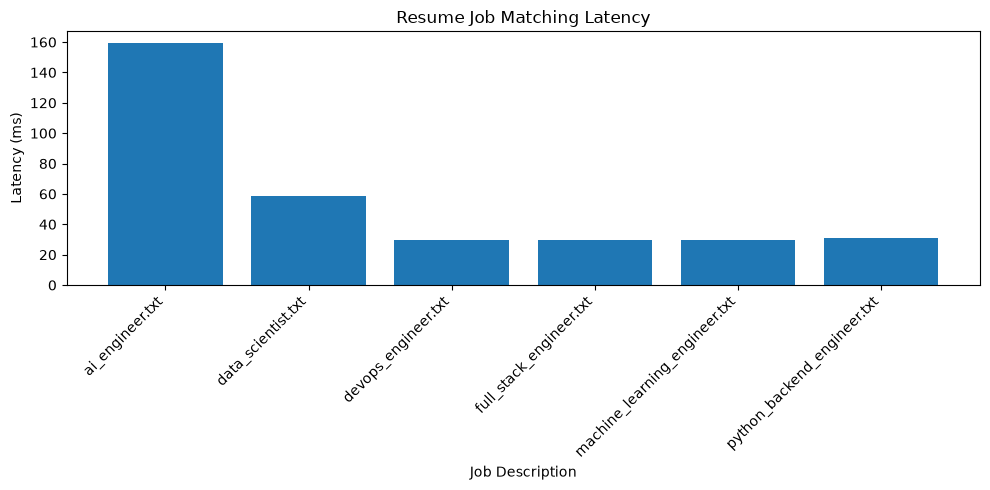

In [14]:
plt.figure(figsize=(10, 5))

plt.bar(
    latency_df["Job"],
    latency_df["Latency (ms)"]
)

plt.xlabel("Job Description")
plt.ylabel("Latency (ms)")
plt.title("Resume Job Matching Latency")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

## 7. Retrieval Evaluation

The system was evaluated using Precision@10 and Recall@10.

### Current Results

| Metric | Result |
|---|---:|
| Average Precision@10 | 62.22% |
| Average Recall@10 | 96.67% |

### Interpretation

The high Recall@10 indicates that the system retrieves most of
the relevant candidates within the Top-10 results.

Precision@10 is lower because some candidates with partial skill
or semantic overlap can still appear in the Top-10 results.

The evaluation uses a synthetic dataset and manually defined
ground truth, so these metrics represent an experimental benchmark
rather than production-level accuracy.

## 8. Conclusion

The Resume RAG system successfully demonstrates a complete
retrieval and job matching pipeline.

### Implemented Components

- Resume file processing
- Section-aware chunking
- Metadata extraction
- Sentence Transformer embeddings
- ChromaDB vector database
- Semantic search
- Hybrid skill matching
- Must-have experience filtering
- Candidate-level ranking
- Match reasoning
- Precision@10 and Recall@10 evaluation
- Latency measurement

### Final Dataset

- 32 resumes
- 6 job descriptions
- 160 indexed chunks
- 384-dimensional embeddings

### Final Evaluation

- Average Precision@10: **62.22%**
- Average Recall@10: **96.67%**

This project demonstrates how vector search, semantic embeddings,
structured metadata and ranking logic can be combined to build an
explainable resume-to-job matching system.